# Problem Set 10 — Inferring cosmology from the Planck CMB spectrum with NPE

**Starter notebook.** The background and the full task descriptions are on the worksheet
(`ProblemSet10_2026.pdf`). This notebook gives you the data loader, the prior, and the plotting
helpers; you fill in the tasks.

We infer the matter and baryon densities $(\Omega_m, \Omega_b)$ around their fiducial Planck 2018
values $\Omega_m = 0.3153 \pm 0.0073$, $\Omega_b = 0.0494 \pm 0.0003$ (i.e.
$\Omega_b h^2 = 0.02238 \pm 0.00015$). The $\pm$ values are the Planck 2018 $1\sigma$ errors, and
the uniform prior spans $\pm 4\sigma$ around the fiducial. All other parameters are held fixed:
$H_0 = 67.32$ km/s/Mpc, $n_s = 0.9661$, $\ln(10^{10}A_s) = 3.045$, $\tau = 0.0543$.

The CAMB simulations are shipped in `planck_camb_tt.h5`, so you do **not** need CAMB
installed — the loader is provided. Reference: the NPE recipe in `lecture_10_NPE.ipynb`. (If you
do have CAMB and want to rebuild the data, run `python make_planck_npe_data.py`.)

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch

from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.diagnostics import run_sbc, check_sbc

from make_planck_npe_data import load_planck_npe_data

%matplotlib inline
torch.set_default_dtype(torch.float32)
torch.manual_seed(7)
rng = np.random.default_rng(7)

theta_labels = [r"$\Omega_m$", r"$\Omega_b$"]
print("setup ok")

I0000 00:00:1782121640.111744  383535 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782121640.571117  383535 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782121643.142261  383535 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


setup ok


## 1. Load the simulations  *(Task 1)*

Load the training bank from `planck_camb_tt.h5` and set up the prior. The file holds
`theta` $=(\Omega_m,\Omega_b)$ and the corresponding **clean** (noise-free) CAMB spectra
`spectra`, plus the multipoles `ell`, the fiducial cosmology, and the Planck observation
(used later). *This cell is provided.*

In [2]:
data = load_planck_npe_data()

theta = torch.as_tensor(data.theta, dtype=torch.float32)        # (n, 2)
spectra = torch.as_tensor(data.spectra, dtype=torch.float32)    # (n, n_ell), CLEAN
ell = data.ell
fid_theta = data.fid_theta
fid_spectrum = data.fid_spectrum

prior = BoxUniform(low=torch.as_tensor(data.prior_low, dtype=torch.float32),
                   high=torch.as_tensor(data.prior_high, dtype=torch.float32))

n_sims, n_features = spectra.shape
print(f"{n_sims} simulations, {n_features} multipoles, ell in [{ell.min():.0f}, {ell.max():.0f}]")
print("prior low :", np.asarray(data.prior_low))
print("prior high:", np.asarray(data.prior_high))
print("fiducial  :", fid_theta)

2000 simulations, 1499 multipoles, ell in [2, 1500]
prior low : [0.2861     0.04806506]
prior high: [0.3445     0.05071291]
fiducial  : [0.3153     0.04938898]


## 2. Plot the prior-predictive spectra  *(Task 2)*

Plot a random sample (~40) of the clean training spectra and overlay the fiducial spectrum, to
see how much the spectrum moves as $(\Omega_m,\Omega_b)$ vary across the prior.

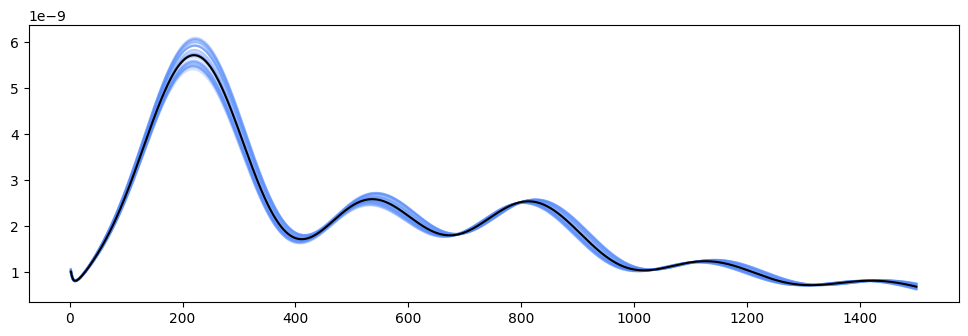

In [6]:
# Task 2: plot ~40 prior-predictive spectra (light blue) and overlay the fiducial (black).
# Hint: idx = rng.choice(n_sims, size=40, replace=False); loop ax.plot(ell, spectra[j].numpy(), ...)
#       then ax.plot(ell, fid_spectrum, "k-", label="fiducial").
# raise NotImplementedError("Task 2: plot the prior-predictive spectra")
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))

idx = rng.choice(n_sims, size=40, replace=False)
for j in idx:
    ax.plot(ell, spectra[j].numpy(), color="C0", alpha=0.25)

ax.plot(ell, fid_spectrum, "k-", label="fiducial")

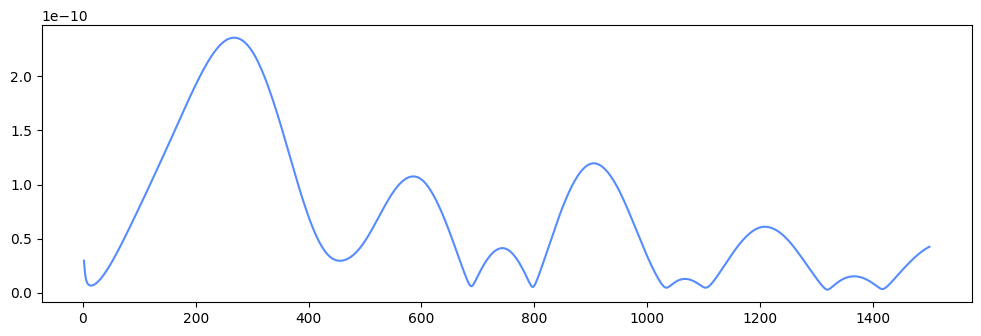

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))
ax.plot(ell, np.std(spectra[idx].numpy(), axis=0))

## 3. Load the Planck data  *(Task 3)*

Extract the official unbinned Planck TT observation from `data` and plot it with its error bars,
together with the fiducial CAMB spectrum. You will infer the cosmology from exactly this data
vector in Task 6.

In [25]:
# Task 3: pull the Planck observation from `data` and plot it with error bars.
# Assign these (used again in Tasks 4, 6, 7):
#   planck_dl, planck_err_minus, planck_err_plus, planck_sigma  =  data.<...>
# Hint: ax.errorbar(ell, planck_dl, yerr=[planck_err_minus, planck_err_plus], fmt=".")
# raise NotImplementedError("Task 3: load and plot the Planck spectrum")

planck_dl, planck_err_minus, planck_err_plus = data.planck_dl, data.planck_err_minus, data.planck_err_plus
planck_sigma = data.planck_sigma

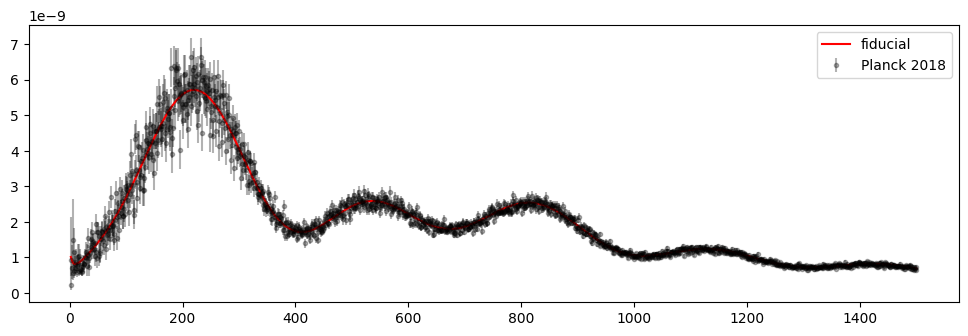

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))
plt.errorbar(ell, planck_dl, yerr=[planck_err_minus, planck_err_plus], label="Planck 2018", color="k", fmt=".", alpha=0.3)
plt.plot(ell, fid_spectrum, "r", label="fiducial")
plt.legend()

## 4. Add measurement errors — cosmic variance  *(Task 4)*

The shipped spectra are **noise-free**. Build a diagonal noise model and apply it to every training
spectrum, so the network learns from data that look like the real, noisy Planck observation.

The per-multipole variance is cosmic variance (which **scales with the spectrum**, Knox formula)
plus a fixed instrument floor:

$$\sigma_\ell^2(\theta) = \underbrace{\frac{2}{(2\ell+1)\,f_{\rm sky}}\,D_\ell(\theta)^2}_{\text{cosmic variance}} + \sigma_{{\rm floor},\ell}^2 .$$

Calibrate the floor **once** so the fiducial cosmology reproduces the Planck error bars:
$\sigma_{{\rm floor},\ell}^2 = \max\!\big(\sigma_\ell^{\rm Planck\,2} - \sigma_{\rm cv}(D_\ell^{\rm fid})^2,\,0\big)$.
Then standardize the features $(x-\mu)/\sigma$ before training.

In [35]:
# Task 4: build the measurement-noise model and apply it to the CLEAN spectra.
#  (a) cosmic_variance_sigma(D_ell) = sqrt(2/((2*ell+1)*F_SKY)) * D_ell           (Knox formula)
#  (b) sigma_floor (fixed): calibrate so the FIDUCIAL total error matches Planck:
#         sigma_floor^2 = clip(planck_sigma^2 - cosmic_variance_sigma(fid_spectrum)^2, 0, None)
#  (c) add_noise(clean): draw Normal(0, sqrt(sigma_cv(clean)^2 + sigma_floor^2)) and add it
#  (d) x_all = standardized (x - mean) / std of the noised spectra
#  Also define standardize(dl) so you can reuse mu/sigma on the Planck vector in Task 6.
F_SKY = 1.0

cosmic_variance_k = np.sqrt(2 / ((2 * ell + 1) * F_SKY))
cosmic_variance_sigma = cosmic_variance_k * fid_spectrum

sigma_floor = np.sqrt(np.clip(planck_sigma ** 2 - cosmic_variance_sigma ** 2, 0, None))

def add_noise(clean, cv_k=0, sigma_floor=0):
    sigma_floor = torch.as_tensor(sigma_floor)
    return clean + torch.randn_like(clean) * torch.sqrt(sigma_floor ** 2 + torch.as_tensor(cv_k)  * clean**2)


In [37]:
noisy_spectra = add_noise(spectra, cosmic_variance_k, sigma_floor)

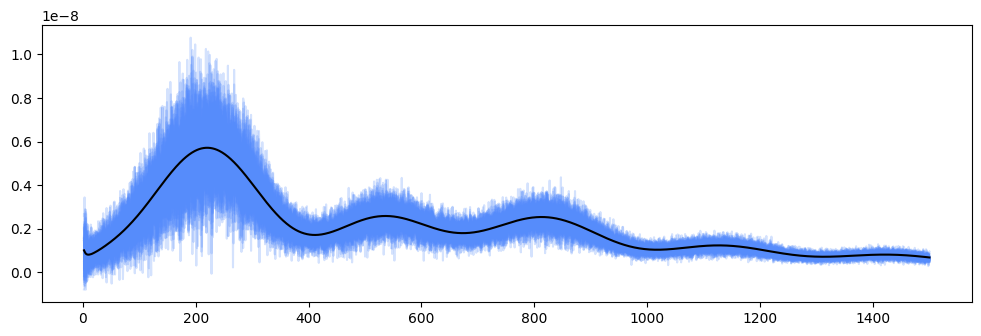

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))
idx = rng.choice(n_sims, size=40, replace=False)
for j in idx:
    ax.plot(ell, noisy_spectra[j].numpy(), color="C0", alpha=0.25)

ax.plot(ell, fid_spectrum, "k-", label="fiducial")

## 5. Train the NPE  *(Task 5)*

Train an amortized NPE, exactly as in `lecture_10_NPE.ipynb` §2:
`NPE(prior)` → `append_simulations(theta, x).train()` → `build_posterior(...)`.
Hold out the **last `n_test = 300`** simulations — you will use them for the coverage test in Task 7.

In [ ]:
# Task 5: train an amortized NPE (mirror lecture_10_NPE.ipynb section 2).
#   inference = NPE(prior=prior)
#   inference.append_simulations(theta_train, x_train).train(max_num_epochs=120)
#   posterior = inference.build_posterior(...)
# Hold out the LAST n_test=300 simulations for the coverage check in Task 7:
#   theta_train, x_train = theta[:-n_test], x_all[:-n_test]
n_test = 300
raise NotImplementedError("Task 5: train the NPE and build the posterior")

## 6. Posterior for the Planck spectrum  *(Task 6)*

Plotting helpers are provided below (2-D credible contours + 1-D marginals, with an optional
truth marker and error bars). *This cell is provided — just run it.*

In [ ]:
from scipy.ndimage import gaussian_filter

def credible_levels_from_samples(samples, bins=80, masses=(0.95, 0.68)):
    H, xe, ye = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins, density=True)
    H = gaussian_filter(H.T, sigma=1.2)
    dx, dy = xe[1] - xe[0], ye[1] - ye[0]
    flat = np.sort(H.ravel())[::-1]
    csum = np.cumsum(flat) * dx * dy
    levels = sorted(flat[min(np.searchsorted(csum, m), len(flat) - 1)] for m in masses)
    xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
    X, Y = np.meshgrid(xc, yc)
    return X, Y, H, levels

def draw_posterior(samples, truth=None, truth_err=None, title="Posterior"):
    samples = np.asarray(samples)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    X, Y, H, levels = credible_levels_from_samples(samples)
    axes[0].contour(X, Y, H, levels=levels, colors=["tab:blue", "navy"], linewidths=[1.2, 1.8])
    axes[0].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.03, color="tab:blue", rasterized=True)
    if truth is not None:
        if truth_err is not None:
            axes[0].errorbar(truth[0], truth[1], xerr=truth_err[0], yerr=truth_err[1],
                             fmt="r*", ms=13, ecolor="r", capsize=3, label="Planck 2018")
        else:
            axes[0].plot(truth[0], truth[1], "r*", ms=13, label="fiducial")
        axes[0].legend(fontsize=8)
    axes[0].set_xlabel(theta_labels[0]); axes[0].set_ylabel(theta_labels[1]); axes[0].set_title(title)
    for j, ax in enumerate(axes[1:]):
        ax.hist(samples[:, j], bins=60, density=True, color="tab:blue", alpha=0.65)
        if truth is not None:
            ax.axvline(truth[j], color="r", ls=":", lw=2)
            if truth_err is not None:
                ax.axvspan(truth[j] - truth_err[j], truth[j] + truth_err[j], color="r", alpha=0.12)
        ax.set_xlabel(theta_labels[j]); ax.set_ylabel("density")
    plt.tight_layout()
    return fig, axes

Now sample the posterior at the Planck data vector and plot it. Mark the Planck 2018 fiducial
with its published 1-$\sigma$ error bars. Does the contour cover the fiducial?

In [ ]:
# Task 6: sample the posterior at the Planck data vector and plot it with draw_posterior().
# Mark the Planck 2018 fiducial with its 1-sigma error bars:
#   omega_b_sigma = 0.00015 / data.h**2 ; truth_err = [0.0073, omega_b_sigma]
# Hint: x_planck = standardize(planck_dl).reshape(1, -1)
#       planck_samples = posterior.sample((20000,), x=x_planck, show_progress_bars=False).numpy()
raise NotImplementedError("Task 6: posterior for the Planck spectrum")

## 7. Checks — coverage & posterior predictive  *(Task 7)*

A neural posterior *always* returns an answer; these checks ask whether to trust it.

**(a) Coverage / SBC.** On the held-out simulations (`theta[-n_test:]`, `x_all[-n_test:]`), run
simulation-based calibration: rank each true value among posterior draws. Flat rank histograms =
calibrated; $\cup$-shaped = overconfident.

**(b) Posterior-predictive check (PPC) — _optional_.** Draw parameters from the Planck posterior
and look at the spectra they imply — they should straddle the Planck data. Without CAMB at
inference time, approximate the simulator by the **nearest pre-computed training spectrum**
(`scipy.spatial.cKDTree`). *(With CAMB you would resimulate exactly via
`make_planck_npe_data.camb_tt_spectrum`.)*

In [ ]:
# Task 7a (coverage / SBC): use the held-out sims theta[-n_test:], x_all[-n_test:].
# Hint: ranks, dap = run_sbc(theta_sbc, x_sbc, posterior, num_posterior_samples=200)
#       ks = check_sbc(ranks, theta_sbc, dap, num_posterior_samples=200)["ks_pvals"]
#       then plot rank histograms (15 bins, range (0,200)); flat = calibrated.
raise NotImplementedError("Task 7a: SBC / coverage check")

In [ ]:
# Task 7b (OPTIONAL — PPC): draw ~60 parameters from the Planck posterior; for each, use the
# nearest training spectrum as a stand-in simulator, and overlay these on the Planck data.
# Hint: from scipy.spatial import cKDTree; tree = cKDTree(theta.numpy())
#       ppc_theta = posterior.sample((60,), x=x_planck, ...).numpy(); _, nn = tree.query(ppc_theta)
raise NotImplementedError("Task 7b (optional): posterior-predictive check")